<a href="https://colab.research.google.com/github/SholaSaliu/malaria_symptoms_triage_helper_project/blob/main/MALARIA_SYMPTOM_TRIAGE_HELPER.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### 1. Imports and Configuration
We begin by importing the necessary libraries for data handling, clinical feature engineering, and high-sensitivity model training.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, roc_auc_score, roc_curve, recall_score)

print("Environment Ready")

Environment Ready


### 2. Data Loading and Clinical Feature Engineering
In this step, we load the dataset and create new binary features based on WHO malaria triage criteria, such as combined neurological risks and severe anemia indicators.

In [6]:
import os

# Check if file exists before loading
file_path = 'ogunMedical.csv'
if os.path.exists(file_path):
    # Load Data
    df = pd.read_csv(file_path)
    df.drop_duplicates(inplace=True)

    # Engineering Clinical Indicators
    # 1. Neurological Risk (Convulsion or Prostration)
    df['neurological_risk'] = df['Convulsion'] | df['prostraction']
    # 2. Severe Anemia/Jaundice combination
    df['severe_anemia_jaundice'] = df['Anemia'] & df['jundice']
    # 3. High Fever Complications
    df['high_fever_rigor'] = df['fever'] & df['rigor'] & df['hyperpyrexia']

    # Define X and y
    X = df.drop(columns=['severe_maleria'])
    y = df['severe_maleria']

    print(f"Data prepared. Total features: {len(X.columns)}")
else:
    print(f"ERROR: '{file_path}' not found. Please upload the dataset to the Colab files section.")

Data prepared. Total features: 20


### 3. Preprocessing and Data Partitioning
We scale numeric features (age) and use a stratified split to ensure that both severe and non-severe cases are equally represented in our training, validation, and test sets.

In [7]:
# Define feature types for the transformer
# Ensuring X and y are available from the previous step
numeric_features = ['age']
binary_features = [col for col in X.columns if col != 'age']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('bin', 'passthrough', binary_features)
    ]
)

# Stratified Split (70% Train, 15% Val, 15% Test)
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.1765, random_state=42, stratify=y_temp
)

print(f"Train size: {len(X_train)}, Val size: {len(X_val)}, Test size: {len(X_test)}")

Train size: 235, Val size: 51, Test size: 51


### 4. Hyperparameter Tuning (Optimized for Recall)
Since missing a severe case is critical, we use `scoring='recall'` in our Grid Search to optimize models for sensitivity.

In [8]:
models = {
    'Random Forest': RandomForestClassifier(random_state=42, class_weight='balanced'),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'Logistic Regression': LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
}

param_grids = {
    'Random Forest': {'classifier__n_estimators': [100, 200], 'classifier__max_depth': [3, 5, 7]},
    'Gradient Boosting': {'classifier__n_estimators': [100, 150], 'classifier__learning_rate': [0.05, 0.1]},
    'Logistic Regression': {'classifier__C': [0.1, 1.0, 10.0]}
}

best_models = {}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Ensure preprocessor is available before the loop
for name, model in models.items():
    pipe = Pipeline(steps=[('preprocessor', preprocessor), ('classifier', model)])
    grid = GridSearchCV(pipe, param_grids[name], cv=cv, scoring='recall', n_jobs=-1)
    grid.fit(X_train, y_train)
    best_models[name] = grid.best_estimator_
    print(f"{name} optimized.")

Random Forest optimized.
Gradient Boosting optimized.
Logistic Regression optimized.


### 5. Final Evaluation and Model Selection
We evaluate performance on the hold-out test set and save the best-performing pipeline.

In [9]:
# Select best model based on validation ROC-AUC
val_scores = {}
for name, m in best_models.items():
    # Calculate probability for the positive class
    y_val_proba = m.predict_proba(X_val)[:, 1]
    score = roc_auc_score(y_val, y_val_proba)
    val_scores[name] = score
    print(f"{name} Val ROC-AUC: {score:.4f}")

# Safely find the best model name
final_model_name = max(val_scores, key=val_scores.get)
final_model = best_models[final_model_name]

print(f"\nFinal Model Selected: {final_model_name}")

# Test Set Metrics
y_pred = final_model.predict(X_test)
print("\nTest Set Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Non-Severe', 'Severe']))

# Save the Pipeline
joblib.dump(final_model, 'malaria_triage_binary_pipeline.pkl')
print("\nPipeline saved successfully as 'malaria_triage_binary_pipeline.pkl'")

Random Forest Val ROC-AUC: 0.5986
Gradient Boosting Val ROC-AUC: 0.6125
Logistic Regression Val ROC-AUC: 0.6211

Final Model Selected: Logistic Regression

Test Set Classification Report:
              precision    recall  f1-score   support

  Non-Severe       0.81      0.67      0.73        33
      Severe       0.54      0.72      0.62        18

    accuracy                           0.69        51
   macro avg       0.68      0.69      0.68        51
weighted avg       0.72      0.69      0.69        51


Pipeline saved successfully as 'malaria_triage_binary_pipeline.pkl'


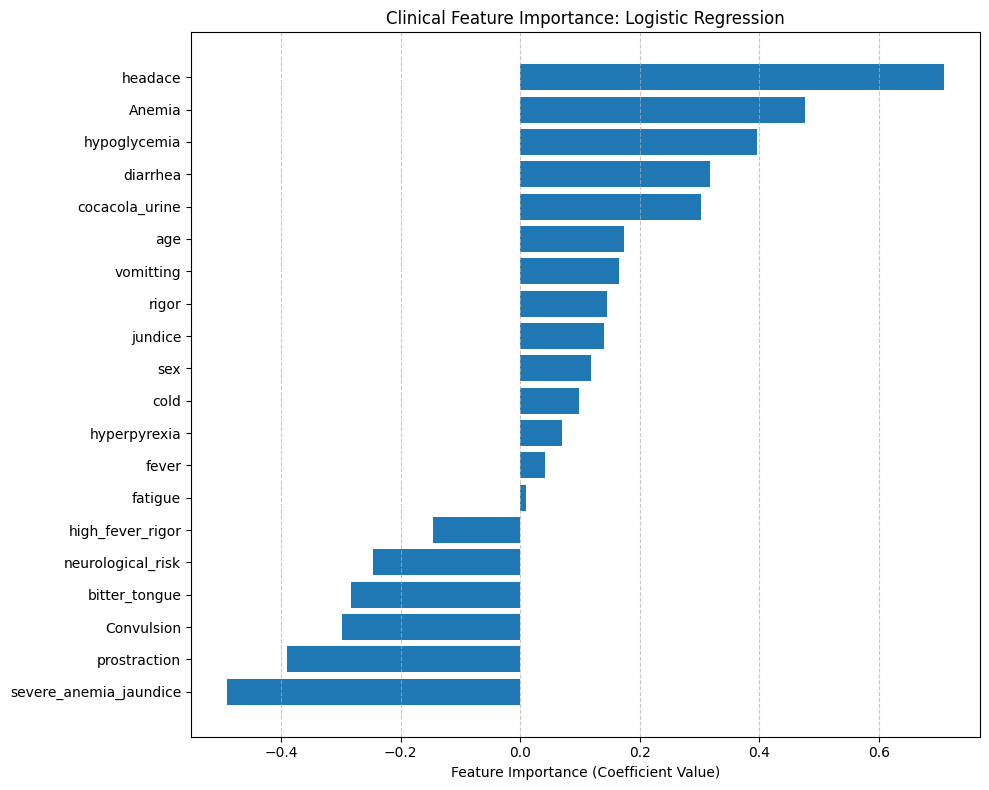

In [10]:
import matplotlib.pyplot as plt
import numpy as np

# Get feature names from the preprocessor
feature_names = numeric_features + binary_features

# Extract coefficients for Logistic Regression
if final_model_name == 'Logistic Regression':
    importance = final_model.named_steps['classifier'].coef_[0]
else:
    importance = final_model.named_steps['classifier'].feature_importances_

# Sort and plot
sorted_idx = np.argsort(importance)
plt.figure(figsize=(10, 8))
plt.barh(np.array(feature_names)[sorted_idx], importance[sorted_idx])
plt.xlabel('Feature Importance (Coefficient Value)')
plt.title(f'Clinical Feature Importance: {final_model_name}')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()